<a href="https://colab.research.google.com/github/SonOfGraceProsper/Waste-Classification-for-Recycling/blob/main/WasteClassificationforRecycling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Extracting files...
Dataset ready!
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 112MB/s]



--- Starting Training ---


Epoch 1/5 [Val]: 100%|██████████| 16/16 [00:47<00:00,  2.96s/it]


Train Loss: 1.2711 | Train Acc: 0.5443
Val Loss: 0.9693 | Val Acc: 0.6976



...

Train Loss: 0.6905 | Train Acc: 0.7684
Val Loss: 0.7265 | Val Acc: 0.7668



Epoch 4/5 [Val]: 100%|██████████| 16/16 [00:48<00:00,  3.05s/it]


Train Loss: 0.6337 | Train Acc: 0.7897
Val Loss: 0.7213 | Val Acc: 0.7510



Epoch 5/5 [Val]: 100%|██████████| 16/16 [00:49<00:00,  3.06s/it]


Train Loss: 0.5801 | Train Acc: 0.7976
Val Loss: 0.6622 | Val Acc: 0.7688



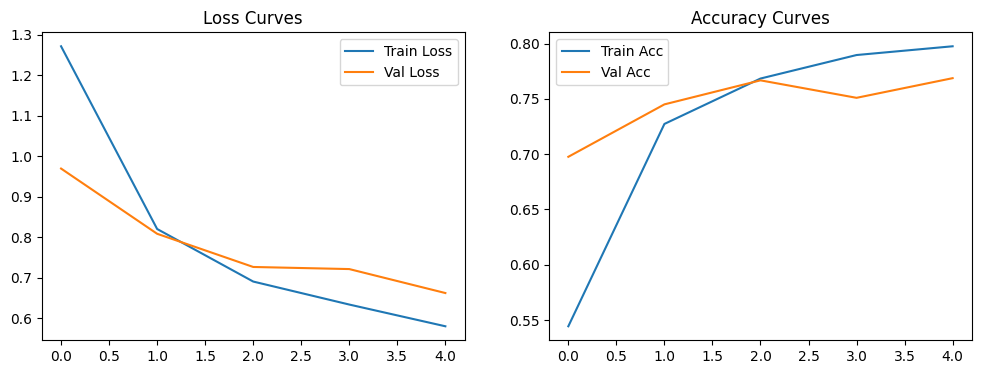

In [18]:
import os
import zipfile
import urllib.request
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dataset_url = "https://github.com/garythung/trashnet/raw/master/data/dataset-resized.zip"
zip_path = "dataset-resized.zip"
data_dir = "dataset-resized"

if not os.path.exists(data_dir):
    print("Downloading dataset...")
    urllib.request.urlretrieve(dataset_url, zip_path)
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall()
    print("Dataset ready!")
else:
    print("Dataset already exists.")

normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        normalize
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize
    ]),
}

full_dataset = datasets.ImageFolder(root=data_dir)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

train_dataset.dataset.transform = data_transforms['train']
val_dataset.dataset.transform = data_transforms['val']

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

class_names = full_dataset.classes
num_classes = len(class_names)

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 5
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\n--- Starting Training ---")
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_train_loss = running_loss / len(train_dataset)
    epoch_train_acc = running_corrects.double() / len(train_dataset)

    model.eval()
    running_val_loss = 0.0
    running_val_corrects = 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            running_val_corrects += torch.sum(preds == labels.data)

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc = running_val_corrects.double() / len(val_dataset)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc.item())
    val_accs.append(epoch_val_acc.item())

    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}\n")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss Curves')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.title('Accuracy Curves')
plt.legend()
plt.show()

In [19]:
!pip install gradio

In [20]:
import gradio as gr
from PIL import Image
import torchvision.transforms as transforms
import torch


preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


def classify_waste(image):
    if image is None:
        return "Please upload an image."

    # Convert image format and apply transformations
    img_tensor = preprocess(image).unsqueeze(0).to(device)

    # Put model in evaluation mode and predict
    model.eval()
    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = torch.nn.functional.softmax(outputs[0], dim=0)

    # Package results into a dictionary of class names and their confidences
    results = {class_names[i]: float(probabilities[i]) for i in range(len(class_names))}
    return results


with gr.Blocks(theme=gr.themes.Soft(primary_hue="green")) as demo:
    gr.Markdown("# ♻️ Automated Waste Classifier")
    gr.Markdown("Upload an image of a household item to instantly see its recycling classification category.")

    with gr.Row():
        with gr.Column():
            image_input = gr.Image(type="pil", label="Upload Trash Image Here")
            submit_btn = gr.Button("Classify Item", variant="primary")
        with gr.Column():
            label_output = gr.Label(num_top_classes=3, label="Predicted Recycling Group")

    submit_btn.click(fn=classify_waste, inputs=image_input, outputs=label_output)


demo.launch(share=True)

/tmp/ipykernel_1221/3640783532.py:33: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft(primary_hue="green")) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2d39535f030c3b256e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
